# Caderno 04: Polarização Afetiva e Dissonância Cognitiva

## Referencial Teórico: Iyengar et al. (2012) e a Polarização Afetiva
A ciência política contemporânea descobriu que os eleitores hoje não se guiam apenas pelo amor à sua própria "tribo", mas pelo ódio ou medo profundo da "tribo oposta". Isso se chama **Polarização Afetiva**.

Quando traduzimos isso para a matemática do Voto Espacial, encontramos o que chamamos de **Dissonância Cognitiva no VAA**. Ocorre quando o eleitor, sem saber o gabarito cego, responde ao questionário com respostas que indicam uma proximidade com o candidato X, mas, por força da Polarização Afetiva, ele marcou o candidato X como "Rejeição Absoluta".

Neste caderno, analisamos quantos eleitores da nossa base estão sofrendo de Dissonância Cognitiva.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import euclidean_distances

sns.set_theme(style='whitegrid')

## 1. Mapeamento da Identidade Negativa
A pergunta da rejeição absoluta captura exatamente quem o eleitor considera o "inimigo".


C:\Users\marce\AppData\Local\Temp\ipykernel_23344\3897843918.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='rejeicao_absoluta', order=df['rejeicao_absoluta'].value_counts().index, palette='Reds_r')


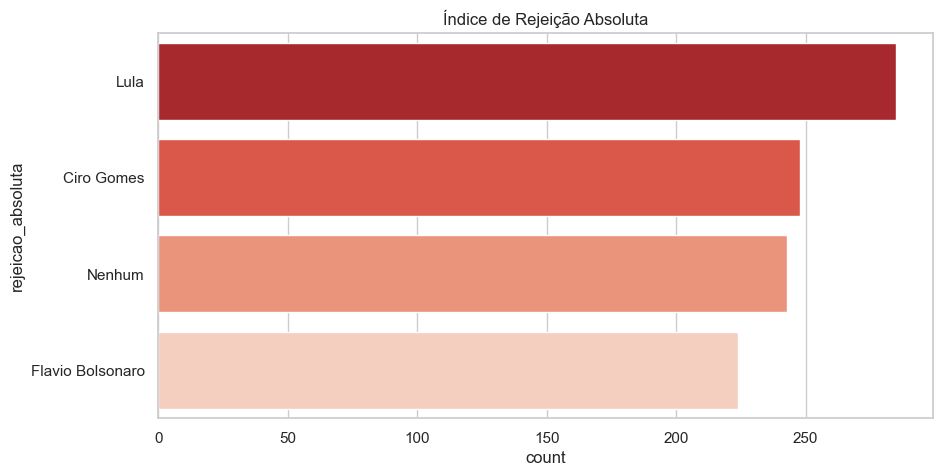

In [2]:
df = pd.read_csv('../data/raw/mock_voters.csv')
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='rejeicao_absoluta', order=df['rejeicao_absoluta'].value_counts().index, palette='Reds_r')
plt.title('Índice de Rejeição Absoluta')
plt.show()

## 2. Aplicando o Veto e Achando a Dissonância


In [3]:
politicos_data = {
    'Político': ['Lula', 'Flavio Bolsonaro', 'Romeu Zema', 'Ciro Gomes'],
    'bloco_d_estatais': [1, 5, 5, 2],
    'bloco_d_tabelamento': [4, 1, 1, 3],
    'bloco_e_punitivismo': [2, 5, 4, 3],
    'bloco_e_educacao': [2, 5, 4, 2],
    'bloco_g_corrupcao': [1, 5, 5, 2],
    'bloco_g_pesquisa': [5, 1, 2, 5],
    'bloco_g_politica_externa': [5, 1, 2, 4]
}
df_cand = pd.DataFrame(politicos_data).set_index('Político')
cols_opiniao = ['bloco_d_estatais', 'bloco_d_tabelamento', 'bloco_e_punitivismo', 'bloco_e_educacao', 'bloco_g_corrupcao', 'bloco_g_pesquisa', 'bloco_g_politica_externa']

dist_matriz = euclidean_distances(df[cols_opiniao].values, df_cand[cols_opiniao].values)
df['candidato_matematico_ideal'] = [df_cand.index[i] for i in np.argmin(dist_matriz, axis=1)]

def recomendacao_com_veto(row, dist_row):
    rejeicao = row['rejeicao_absoluta']
    dist_corrigida = dist_row.copy()
    if rejeicao in df_cand.index:
        idx_rejeitado = df_cand.index.get_loc(rejeicao)
        dist_corrigida[idx_rejeitado] = np.inf
    return df_cand.index[np.argmin(dist_corrigida)]

df['candidato_final'] = [recomendacao_com_veto(row, dist_matriz[i]) for i, row in df.iterrows()]
df['dissonancia'] = df['candidato_matematico_ideal'] != df['candidato_final']

print(f"{df['dissonancia'].mean() * 100:.2f}% dos eleitores possuem dissonância cognitiva (rejeitam quem é tecnicamente mais parecido com eles).")

16.00% dos eleitores possuem dissonância cognitiva (rejeitam quem é tecnicamente mais parecido com eles).
